<a href="https://colab.research.google.com/github/Kethellem/cursopython/blob/main/C%C3%B3pia_de_Projeto_de_Doen%C3%A7%C3%A3s_Cardiovasculares_Regress%C3%A3o_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

Comece carregando e tratando a bae de dados.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CARDIO_BASE.csv to CARDIO_BASE (3).csv


In [ ]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')
base.head()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0


In [ ]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [ ]:
# garantir string
base['weight'] = base['weight'].astype(str).str.strip()

# trocar vírgula por ponto, se existir
base['weight'] = base['weight'].str.replace(',', '.', regex=False)

# remover qualquer coisa que não seja número ou ponto
base['weight'] = base['weight'].str.replace(r'[^0-9\.]', '', regex=True)

# converter para float
base['weight'] = base['weight'].astype(float)

base['weight'].head(), base['weight'].dtype

(0    62.0
 1    85.0
 2    64.0
 3    82.0
 4    56.0
 Name: weight, dtype: float64,
 dtype('float64'))

In [ ]:
base.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
cholesterol,0
gluc,0
smoke,0
alco,0
active,0
cardio_disease,0


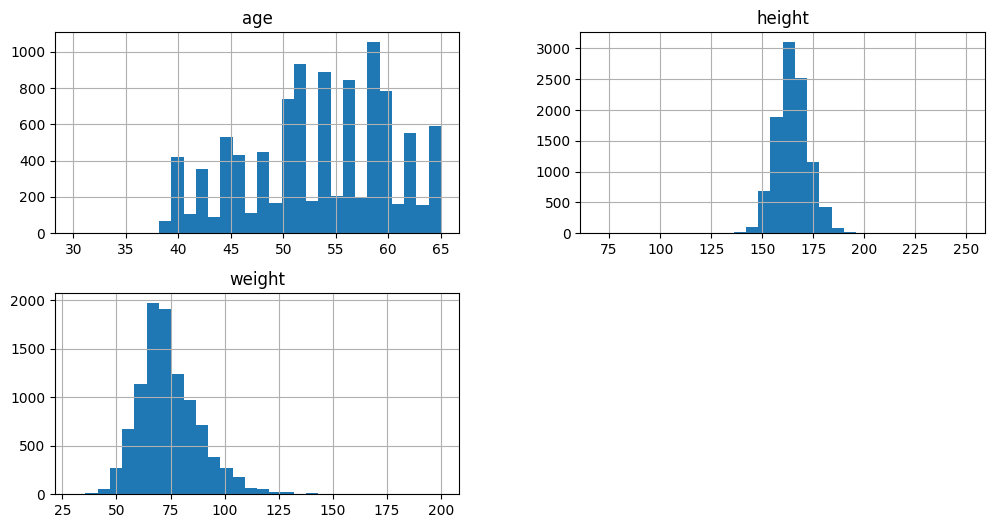

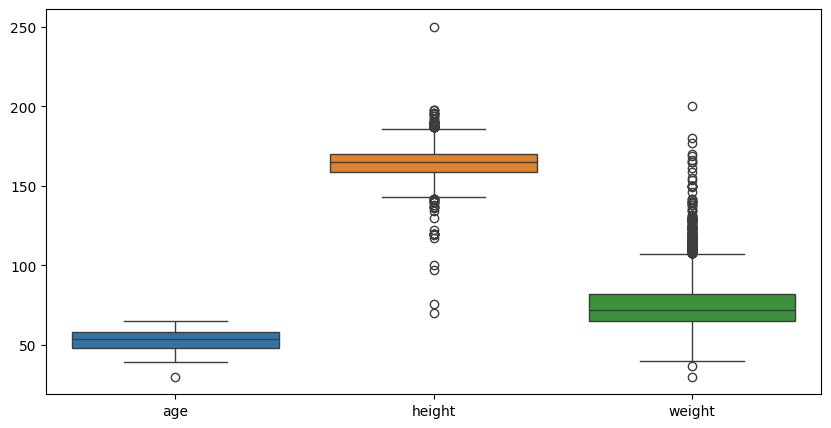

In [ ]:
base[['age','height','weight']].hist(bins=30, figsize=(12,6))
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=base[['age','height','weight']])
plt.show()

In [ ]:
# altura entre 120 e 220 cm
base = base[(base['height'] >= 120) & (base['height'] <= 220)]

# peso entre 45 e 180 kg
base = base[(base['weight'] >= 45) & (base['weight'] <= 180)]

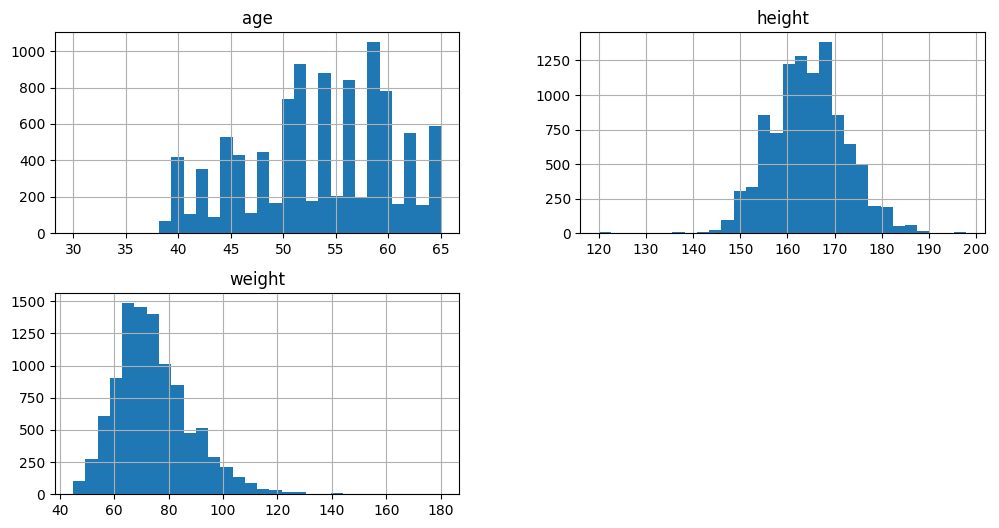

In [ ]:
base[['age','height','weight']].hist(bins=30, figsize=(12,6))
plt.show()

In [ ]:
base['cardio_disease'].value_counts(), base['cardio_disease'].value_counts(normalize=True)*100

(cardio_disease
 1    5016
 0    4943
 Name: count, dtype: int64,
 cardio_disease
 1    50.366503
 0    49.633497
 Name: proportion, dtype: float64)

In [ ]:
features = ['age','gender','height','weight','cholesterol','gluc','smoke','alco','active']
target = 'cardio_disease'

X = base[features]
y = base[target]

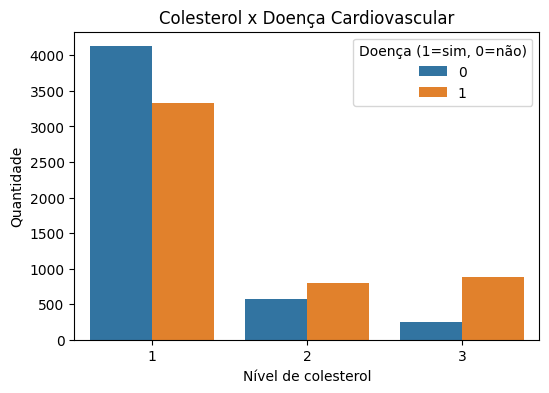

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=base, x='cholesterol', hue='cardio_disease')
plt.title('Colesterol x Doença Cardiovascular')
plt.xlabel('Nível de colesterol')
plt.ylabel('Quantidade')
plt.legend(title='Doença (1=sim, 0=não)')
plt.show()

- níveis mais altos de colesterol (2, 3) tendem a ter proporção maior de cardio_disease = 1
- isso sugere que colesterol elevado está associado a maior risco de doença cardiovascular.


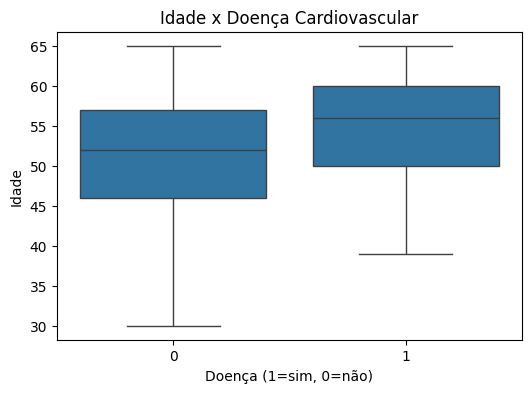

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=base, x='cardio_disease', y='age')
plt.title('Idade x Doença Cardiovascular')
plt.xlabel('Doença (1=sim, 0=não)')
plt.ylabel('Idade')
plt.show()

- a mediana de idade dos pacientes com doença (cardio_disease = 1) é maior
- a distribuição de idade dos doentes é deslocada para cima
→ quanto mais velho, maior a chance de ter doença cardiovascular.


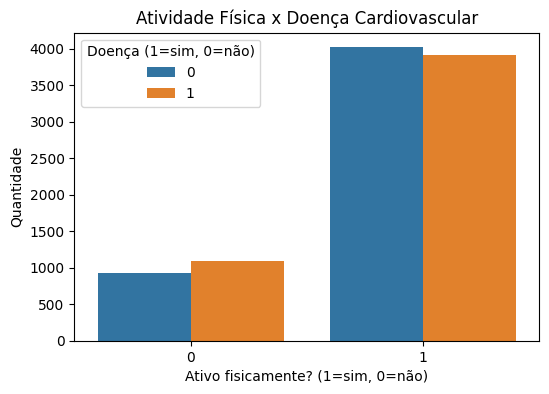

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=base, x='active', hue='cardio_disease')
plt.title('Atividade Física x Doença Cardiovascular')
plt.xlabel('Ativo fisicamente? (1=sim, 0=não)')
plt.ylabel('Quantidade')
plt.legend(title='Doença (1=sim, 0=não)')
plt.show()

- entre os não ativos (active = 0), a proporção de cardio_disease = 1 é maior
- entre os ativos (active = 1), a proporção de doentes tende a ser menor
→ isso reforça a ideia de que atividade física tem papel protetor.


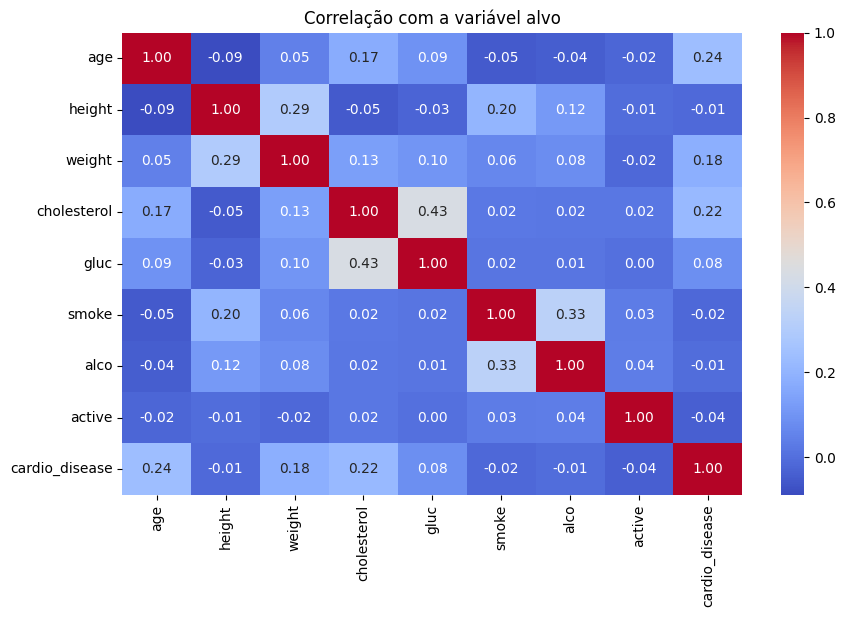

In [ ]:
cols = ['age','height','weight','cholesterol','gluc','smoke','alco','active','cardio_disease']
plt.figure(figsize=(10,6))
sns.heatmap(base[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação com a variável alvo')
plt.show()

 1. Idade (age) é a variável mais correlacionada com doença cardiovascular
O envelhecimento é um dos fatores de risco mais conhecidos e isso aparece claramente nos dados.
2. Colesterol (cholesterol) apresenta correlação moderada com o alvo
Colesterol elevado é um marcador importante de risco cardiovascular.
3. Glicose (gluc) também tem correlação positiva com o alvo
Alterações metabólicas contribuem para o risco de forma significativa





In [ ]:
base.corr()['cardio_disease'].sort_values(ascending=False)

,cardio_disease
cardio_disease,1.000000
age,0.235261
cholesterol,0.220738
weight,0.183589
gluc,0.082581
gender,0.000997
alco,-0.006198
height,-0.012536
smoke,-0.019206
active,-0.038960


- age → correlação mais forte
- cholesterol → moderada
- gluc → moderada
- weight / height → fracas
- smoke / alco / active → muito fracas


In [ ]:
X = base[['age','gender','height','weight','cholesterol','gluc','smoke','alco','active']]
y = base['cardio_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

- O modelo (Regressão Logística) é sensível à escala das variáveis.
- Variáveis como age, height, weight têm escalas muito diferentes.
- Sem padronização, variáveis maiores dominam o cálculo dos coeficientes.
  Vamos padronizar somente variáveis numéricas.


In [ ]:
scaler = StandardScaler()

num_cols = ['age','height','weight']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [ ]:
print("X_train:")
display(X_train.head())

print("y_train:")
print(y_train.head())

print("X_test:")
display(X_test.head())

print("y_test:")
print(y_test.head())

X_train:


,age,gender,height,weight,cholesterol,gluc,smoke,alco,active
58,44,2,172,84.0,1,1,1,0,1
7379,57,1,156,55.0,1,1,0,0,1
1434,58,2,169,85.0,1,1,1,1,0
6557,48,2,170,72.0,1,1,1,0,1
4876,53,1,159,83.0,1,1,0,0,1


y_train:
58      1
7379    1
1434    0
6557    1
4876    1
Name: cardio_disease, dtype: int64
X_test:


,age,gender,height,weight,cholesterol,gluc,smoke,alco,active
1461,62,2,174,74.0,1,1,0,0,0
7314,57,1,161,94.0,1,2,0,0,0
8684,55,1,162,63.0,1,1,0,0,1
9023,52,1,165,75.0,1,1,0,0,1
8728,56,1,158,60.0,1,1,0,0,1


y_test:
1461    1
7314    1
8684    0
9023    1
8728    0
Name: cardio_disease, dtype: int64


In [ ]:
 #Treinar o modelo com a base balanceada
model = LogisticRegression(max_iter=1000)
model.fit(X_train_bal, y_train_bal)

# Previsões no conjunto de teste
y_pred = model.predict(X_test)


NameError: name 'X_train_bal' is not defined